In [1]:
import logging
import os
import sys
import traceback
from sklearn.preprocessing import LabelEncoder

from tqdm import tqdm 

from hydra import initialize, compose
import numpy as np
import pandas as pd
from omegaconf import DictConfig
import scanpy as sc
import torch

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import sys 
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import get_forward_model

from torch.utils.data import TensorDataset, DataLoader
import yaml

In [2]:
with initialize(config_path="../../../../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

In [3]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [4]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

# Read old and new data

In [5]:
adata_old_experiments = sc.read_h5ad("../../../../../../project_folder/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")
adata_loop2 = sc.read_h5ad("../../../../../../project_folder/data/gdrive/loop2/BloodPlus_Loop2_logicle_500k.h5ad")
adata_loop2.obs["cell_type"] = "Unannotated"

In [6]:
adata_loop2

AnnData object with n_obs × n_vars = 499992 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type', 'Experiment_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_umap'
    layers: 'positi

In [7]:
# sc.pp.neighbors(adata_loop2)
# sc.tl.umap(adata_loop2)

## Annotate cells based on markers 

In [8]:
adata_old_experiments.var

,n,channel,marker,PnB,PnE,PnR,PnD,signal_type,antibody
CD49c,8,BUV395-A,CD49c : BUV395 - Area,32,"0,0",1e+06,,area,CD49c
CD41a,9,BUV563-A,CD41a : BUV563 - Area,32,"0,0",1e+06,,area,CD41a
CD117,10,BUV615-A,CD117 : BUV615 - Area,32,"0,0",1e+06,,area,CD117
CD38,11,BUV661-A,CD38 : BUV661 - Area,32,"0,0",1e+06,,area,CD38
HLADR,12,BUV737-A,HLADR : BUV737 - Area,32,"0,0",1e+06,,area,HLADR
EPCR,13,BV421-A,EPCR : BV421 - Area,32,"0,0",1e+06,,area,EPCR
CD135,14,BV480-A,CD135 : BV480 - Area,32,"0,0",1e+06,,area,CD135
CD56,15,BV605-A,CD56 : BV605 - Area,32,"0,0",1e+06,,area,CD56
CD15,16,BV650-A,CD15 : BV650 - Area,32,"0,0",1e+06,,area,CD15
CD123,17,BV711-A,CD123 : BV711 - Area,32,"0,0",1e+06,,area,CD123


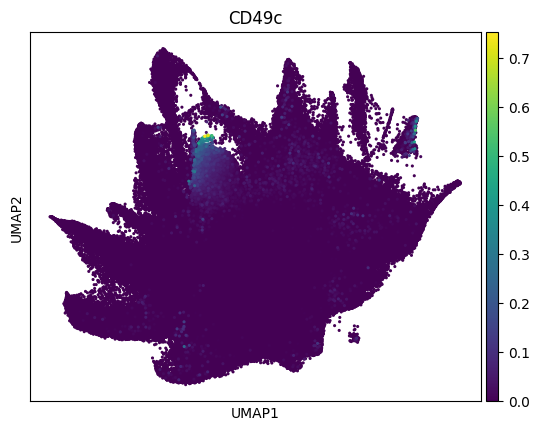

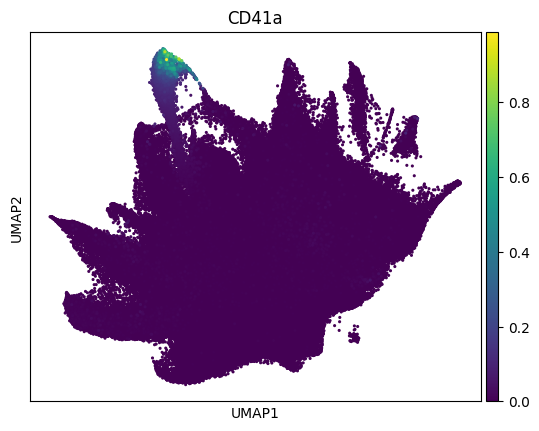

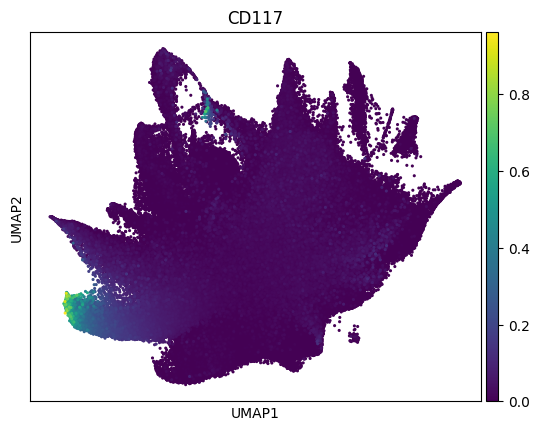

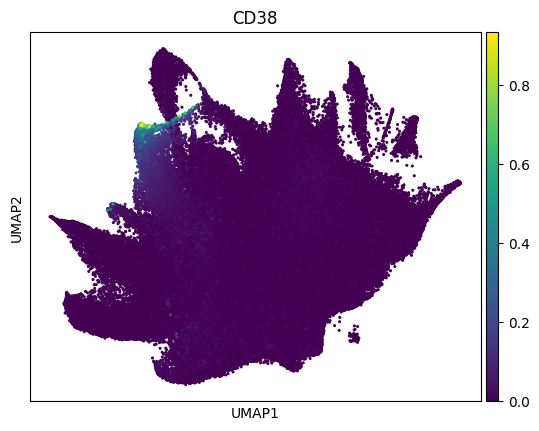

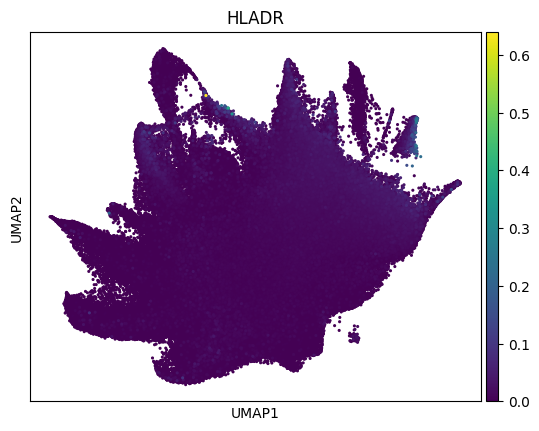

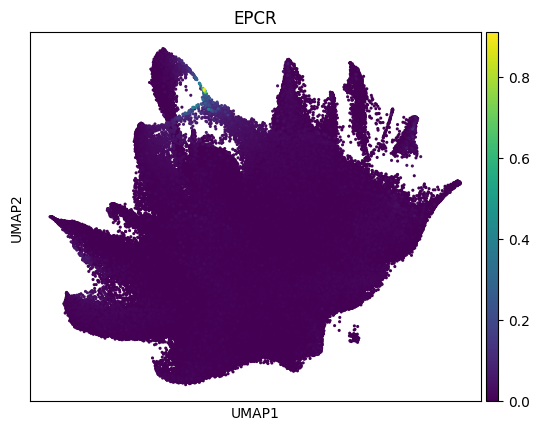

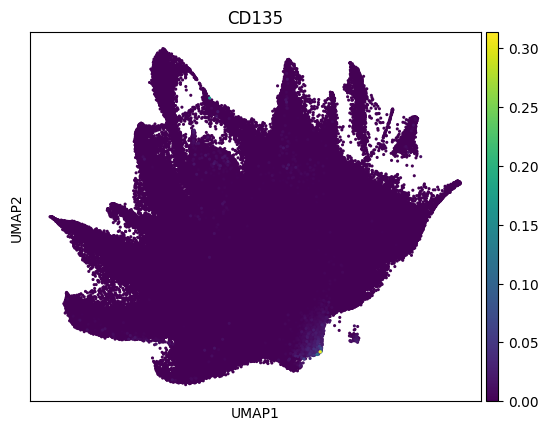

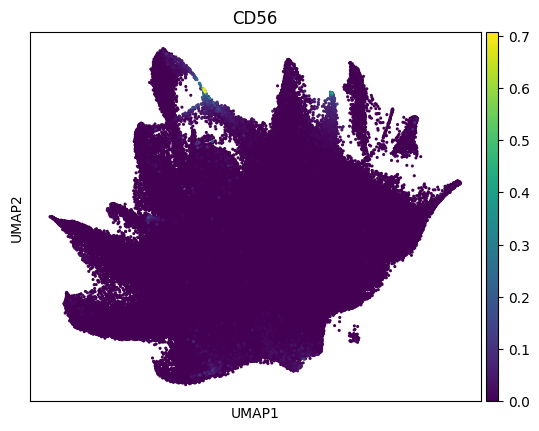

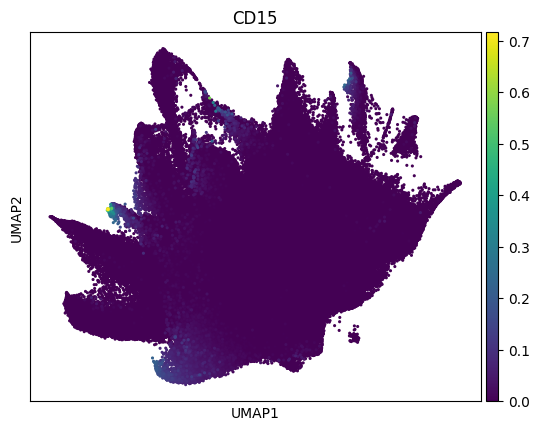

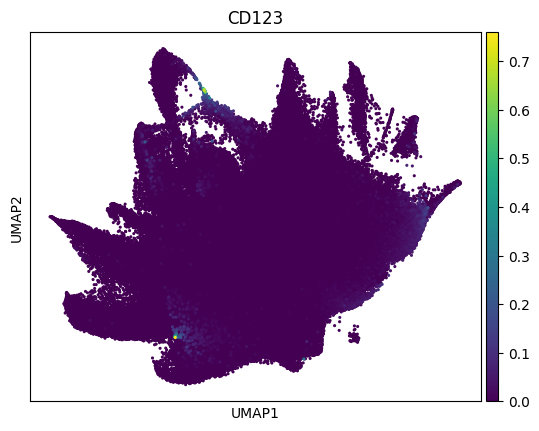

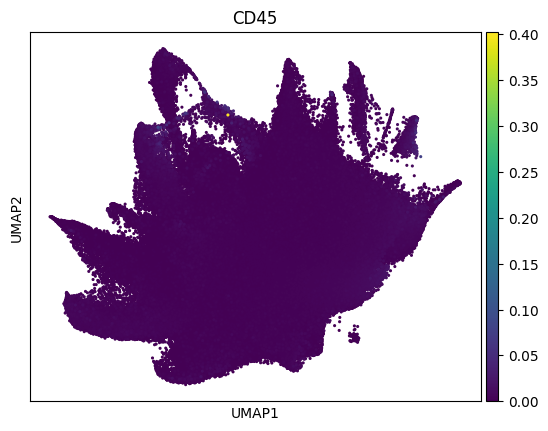

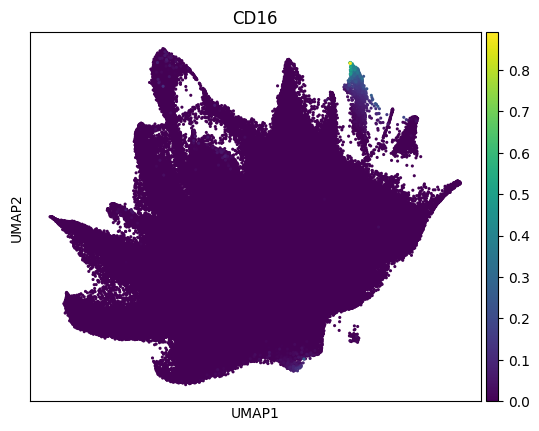

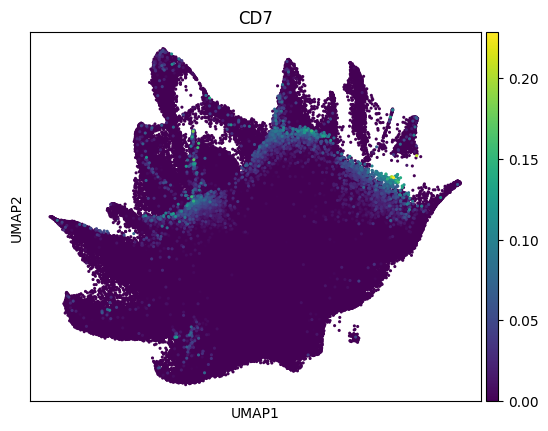

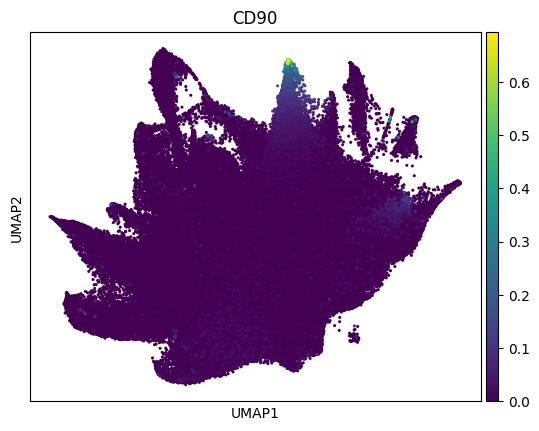

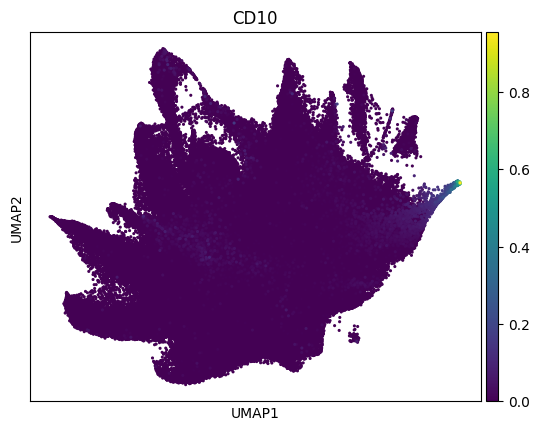

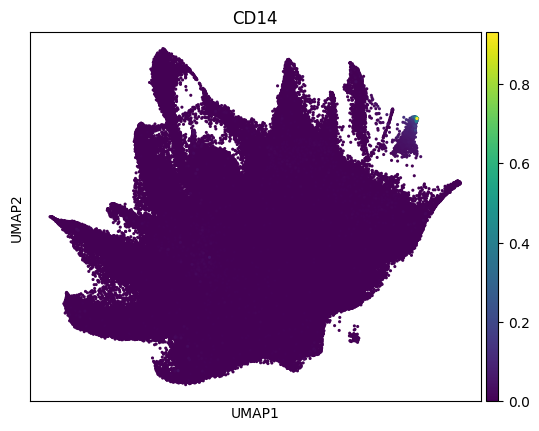

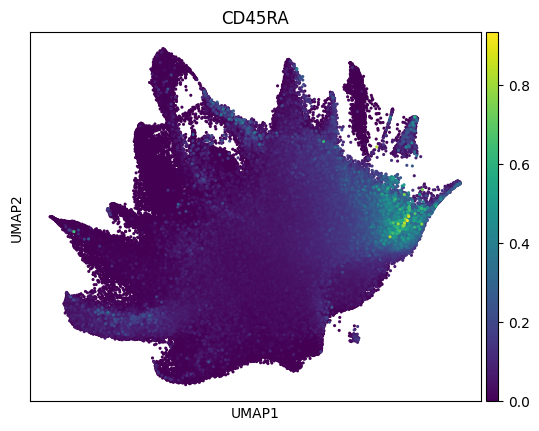

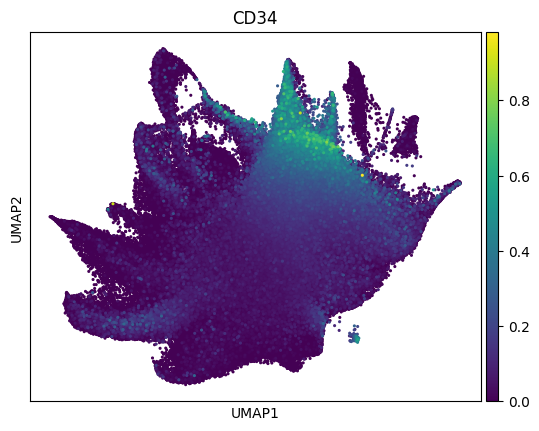

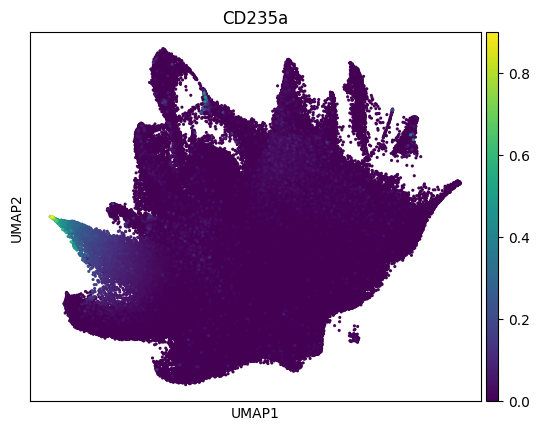

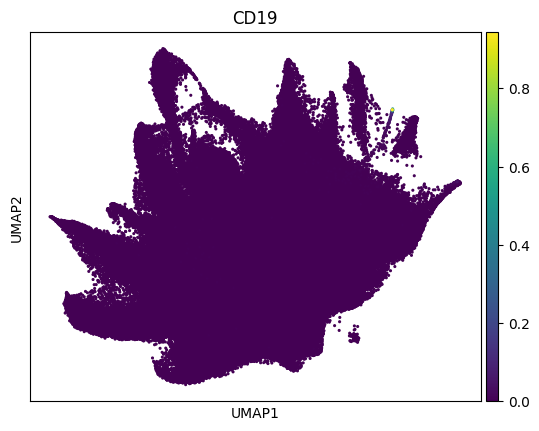

In [9]:
for marker in adata_old_experiments.var.index:
    sc.pl.umap(adata_old_experiments, s=20, color=marker)

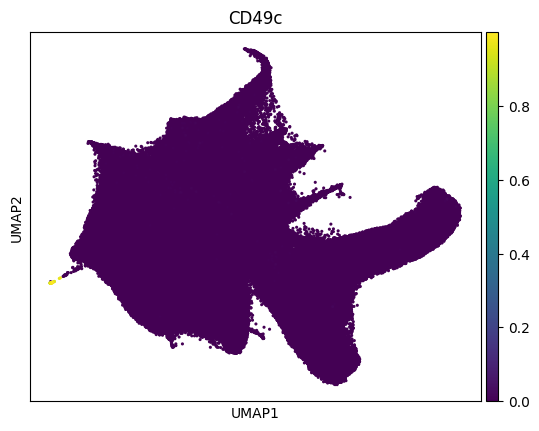

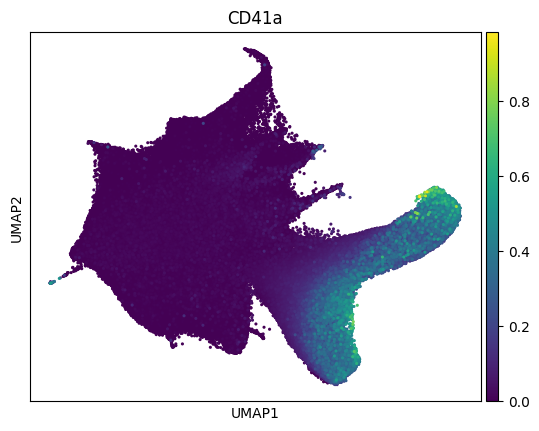

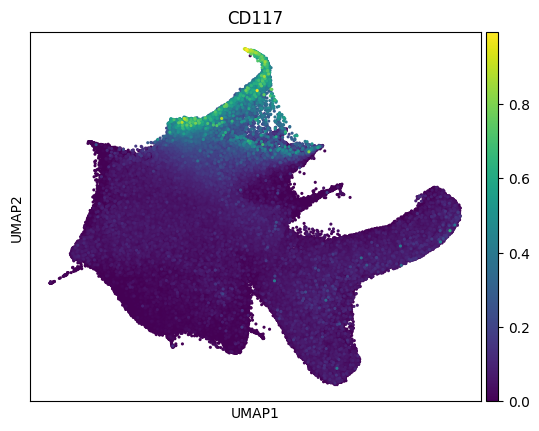

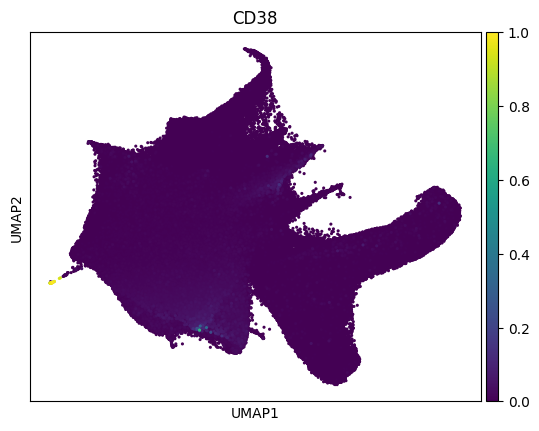

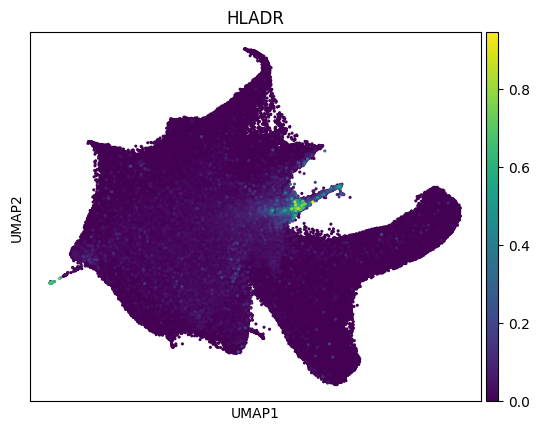

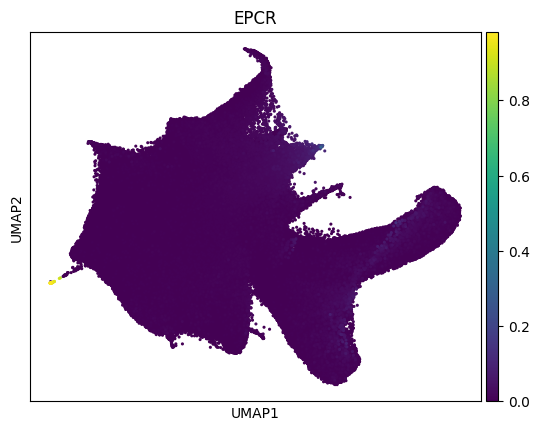

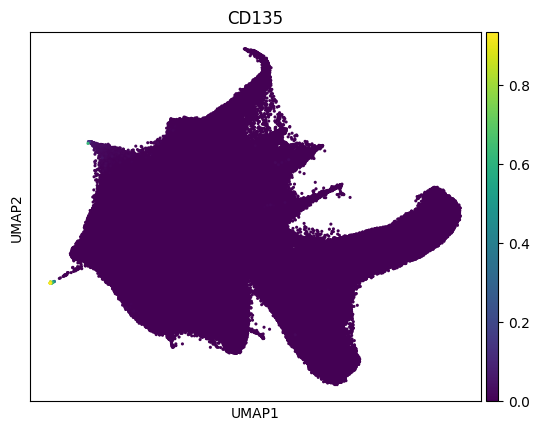

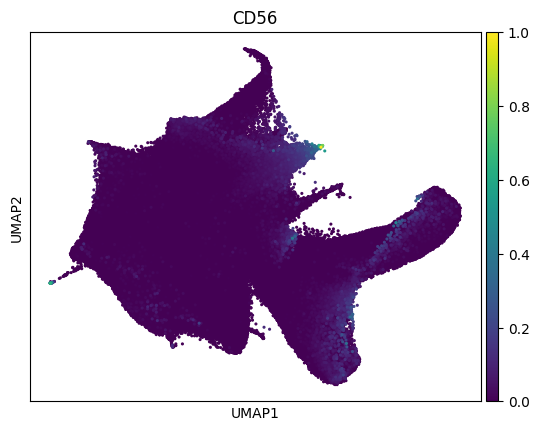

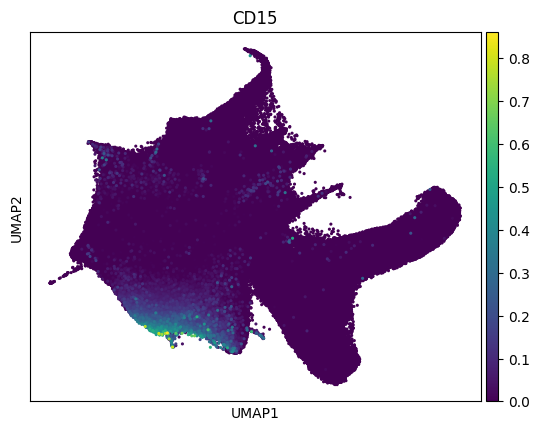

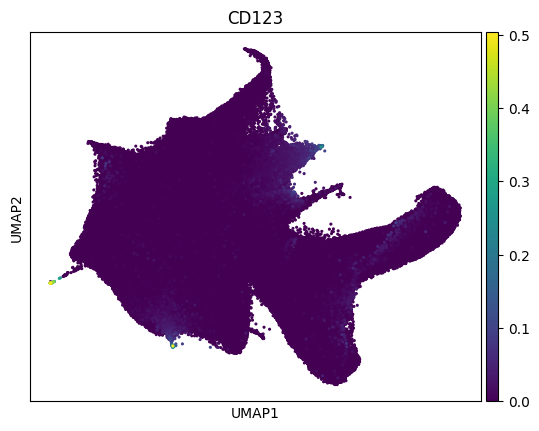

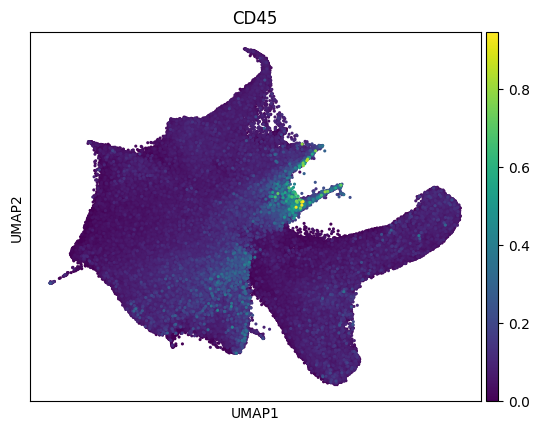

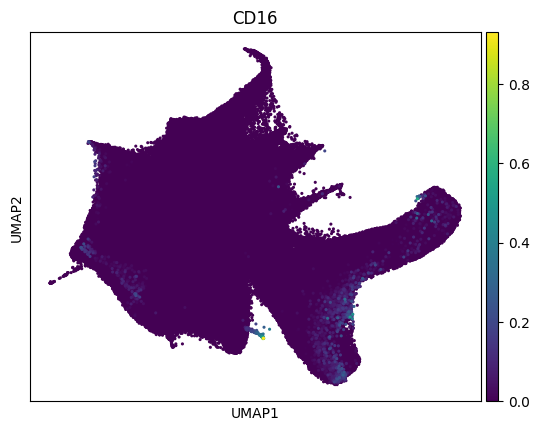

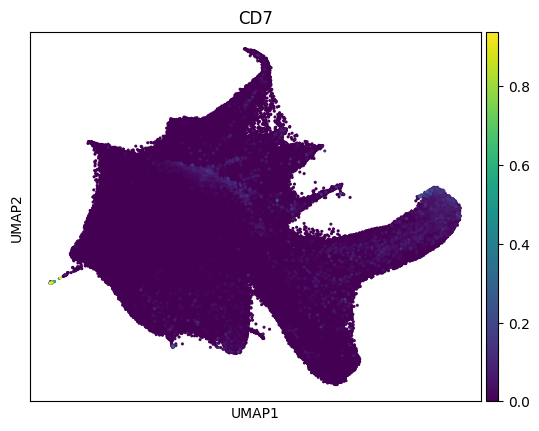

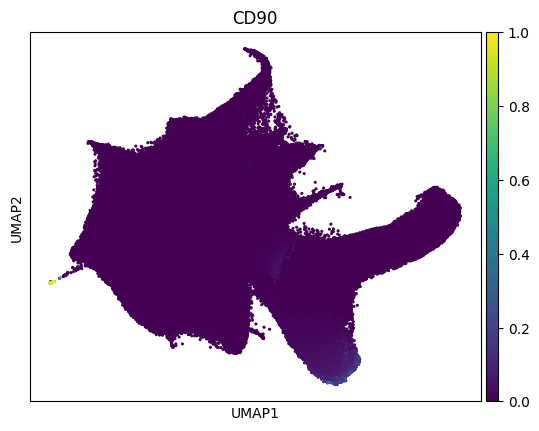

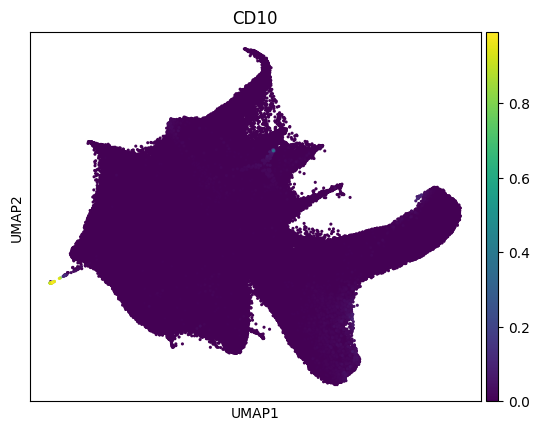

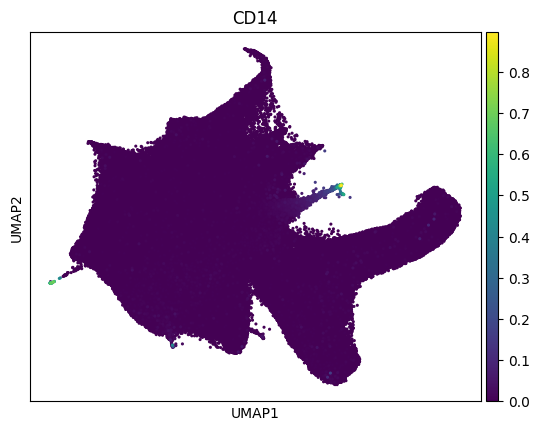

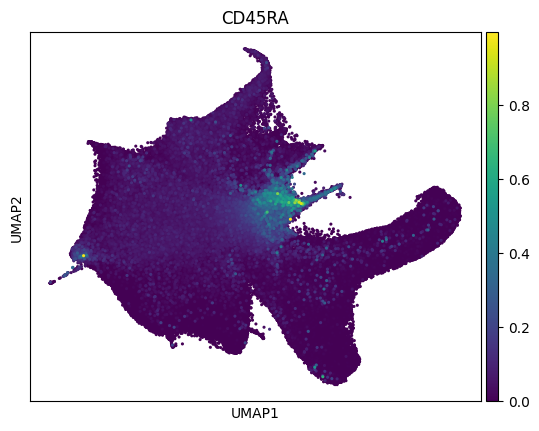

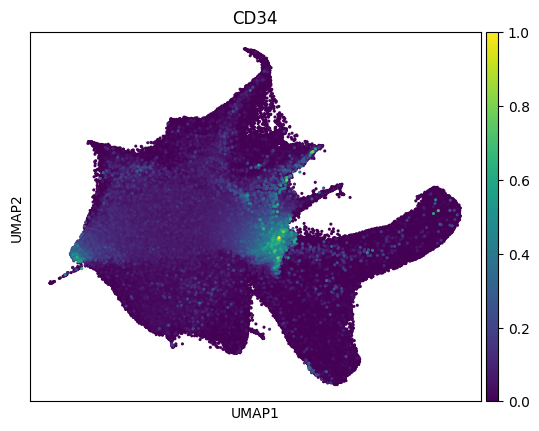

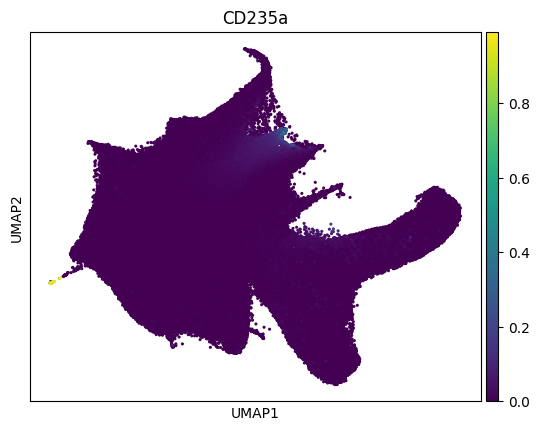

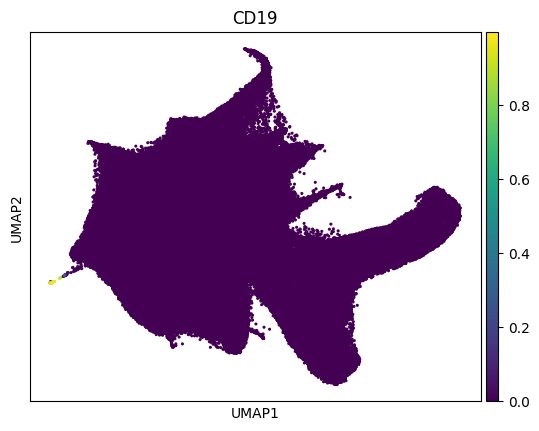

In [10]:
for marker in adata_loop2.var.index:
    sc.pl.umap(adata_loop2, s=20, color=marker)

In [11]:
adata_loop2.write_h5ad("../../../../../../project_folder/data/gdrive/loop2/BloodPlus_Loop2_logicle_500k.h5ad")

## Train marker classifier 

In [12]:
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from tqdm import tqdm

# =========================================================
# Prepare data
# =========================================================

X = adata_old_experiments.X

# Convert sparse matrix -> dense if needed
if hasattr(X, "toarray"):
    X = X.toarray()

# Labels
y = adata_old_experiments.obs["cell_type"].values

# Encode string labels -> integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# =========================================================
# PyTorch tensors
# =========================================================

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)

train_loader = DataLoader(
    dataset,
    batch_size=2048,
    shuffle=True
)

# Separate loader for evaluation
eval_loader = DataLoader(
    dataset,
    batch_size=2048,
    shuffle=False
)

# =========================================================
# Model
# =========================================================

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X.shape[1]
hidden_dim = 512
output_dim = len(le.classes_)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim
).to(device)

# =========================================================
# Optimization
# =========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

# =========================================================
# Training
# =========================================================

n_epochs = 30

for epoch in range(n_epochs):

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{n_epochs}"
    ):

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")

# =========================================================
# Evaluate on training set
# =========================================================

model.eval()

all_preds = []

with torch.no_grad():

    for X_batch, _ in eval_loader:

        X_batch = X_batch.to(device)

        logits = model(X_batch)

        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())

y_pred = np.concatenate(all_preds)

print(
    classification_report(
        y_encoded,
        y_pred,
        target_names=le.classes_
    )
)

Epoch 1/30: 100%|██████████| 231/231 [00:14<00:00, 15.87it/s]


Epoch 1/30 | Loss: 2.1944


Epoch 2/30: 100%|██████████| 231/231 [00:02<00:00, 84.18it/s] 


Epoch 2/30 | Loss: 0.9233


Epoch 3/30: 100%|██████████| 231/231 [00:02<00:00, 91.03it/s] 


...

Epoch 28/30 | Loss: 0.2318


Epoch 29/30: 100%|██████████| 231/231 [00:02<00:00, 93.19it/s] 


Epoch 29/30 | Loss: 0.2306


Epoch 30/30: 100%|██████████| 231/231 [00:02<00:00, 90.93it/s] 


Epoch 30/30 | Loss: 0.2295
              precision    recall  f1-score   support

    CD14Mono       1.00      0.99      0.99       667
    CD16Mono       0.95      0.92      0.94      1213
 CyclingPro1       0.96      0.95      0.96     10060
 CyclingPro2       0.94      0.91      0.92       934
   Early_GMP       0.87      0.87      0.87     36442
 EosBasMast1       0.95      0.95      0.95     22697
 EosBasMast2       0.92      0.91      0.91     31986
 EosBasMast3       0.86      0.79      0.82      1964
      EryPro       0.96      0.95      0.96     16958
  GMP-Neutro       0.89      0.91      0.90     73575
 GMP_cycling       0.87      0.89      0.88     28875
        HSCs       0.95      0.94      0.95      2668
    LMPP-CLP       0.91      0.91      0.91     40358
         MLP       0.93      0.91      0.92      1629
         MPP       0.94      0.94      0.94     82350
  MPP_MgkEry       0.91      0.91      0.91     24932
  MgKEryPro1       0.90      0.89      0.90     62093


In [13]:
X_new = adata_loop2.X

# Convert sparse matrix -> dense if needed
if hasattr(X_new, "toarray"):
    X_new = X_new.toarray()

# Convert to PyTorch tensor
X_new_tensor = torch.tensor(
    X_new,
    dtype=torch.float32
)

# DataLoader
new_loader = DataLoader(
    X_new_tensor,
    batch_size=2048,
    shuffle=False
)

# =========================================================
# Predict cell types
# =========================================================

model.eval()

all_preds = []

with torch.no_grad():

    for X_batch in tqdm(new_loader, desc="Predicting"):

        X_batch = X_batch.to(device)

        logits = model(X_batch)

        preds = torch.argmax(logits, dim=1)

        all_preds.append(
            preds.cpu().numpy()
        )

# Concatenate all batches
y_pred_encoded = np.concatenate(all_preds)

# Decode integer labels -> original cell type names
y_pred_labels = le.inverse_transform(y_pred_encoded)

# =========================================================
# Add predictions to AnnData.obs
# =========================================================

adata_loop2.obs["cell_type"] = y_pred_labels

Predicting: 100%|██████████| 245/245 [00:00<00:00, 380.56it/s]


In [14]:
adata_loop2.obs["cell_type"]

134421-20     GMP-Neutro
25066-44      GMP-Neutro
107346-56       pre_cDC2
197002-20    GMP_cycling
64000-44      MgKEryPro1
                ...     
4203-23              MPP
2402-23      GMP_cycling
5479-11              MPP
64532-11       Early_GMP
41391-11      GMP-Neutro
Name: cell_type, Length: 499992, dtype: object

## Refine marker based annotation

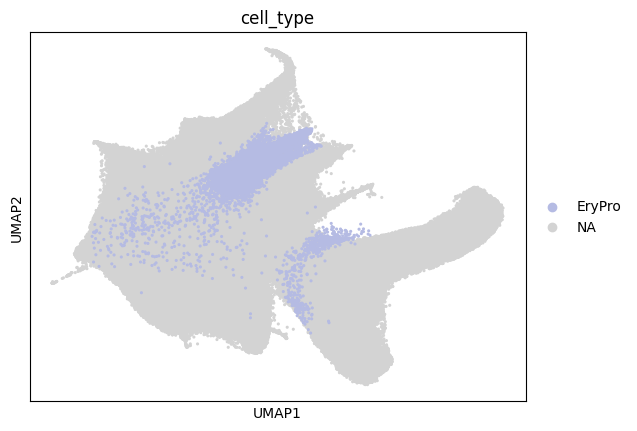

In [15]:
sc.pl.umap(adata_loop2, color="cell_type", groups="EryPro", s=20)

In [16]:
adata_loop2_copy = adata_loop2.copy()

# Extract CD41a values
cd41_vals = adata_loop2_copy[:, "CD41a"].X

# Convert sparse matrix if needed
if hasattr(cd41_vals, "toarray"):
    cd41_vals = cd41_vals.toarray().flatten()
else:
    cd41_vals = np.array(cd41_vals).flatten()

# Choose percentile threshold
percentile = 87
threshold = np.percentile(cd41_vals, percentile)

# Flag cells above threshold
adata_loop2_copy.obs["has_cd41"] = cd41_vals > threshold

In [17]:
# Extract CD41a values
cd235_vals = adata_loop2_copy[:, "CD235a"].X

# Convert sparse matrix if needed
if hasattr(cd235_vals, "toarray"):
    cd235_vals = cd235_vals.toarray().flatten()
else:
    cd235_vals = np.array(cd235_vals).flatten()

# Choose percentile threshold
percentile = 80
threshold = np.percentile(cd235_vals, percentile)

# Flag cells above threshold
adata_loop2_copy.obs["has_235"] = cd235_vals > threshold

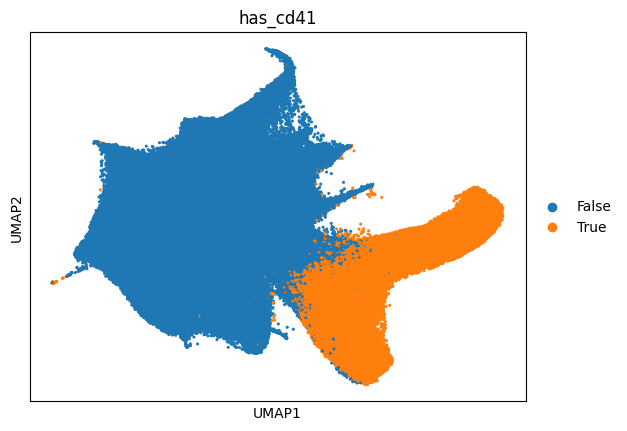

In [18]:
sc.pl.umap(adata_loop2_copy, color="has_cd41", s=20)

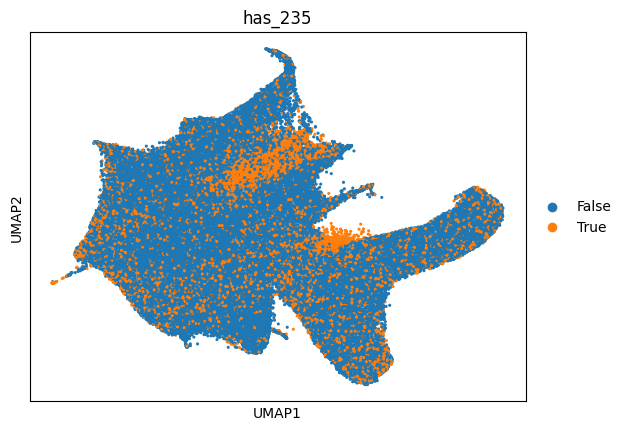

In [19]:
sc.pl.umap(adata_loop2_copy, color="has_235", s=20)

Refine annot

In [20]:
adata_loop2_copy.obs.loc[
    adata_loop2_copy.obs["has_cd41"],
    "cell_type"
] = "late_MgkPro"

# Check enrichment 

In [21]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [22]:
# adata_loop2.obs["cell_type"] = ct_predictions
adata_loop2_copy.obs["cell_type"] = adata_loop2_copy.obs["cell_type"].astype("category")

In [23]:
protocols_loop2 = adata_loop2_copy.obs.loc[:, protocol_cols + ["experiment_number"]] 
protocols_loop2 = protocols_loop2.astype(float)

In [24]:
unique_protocols = pd.DataFrame(np.unique(protocols_loop2, axis=0))
unique_protocols.columns = protocols_loop2.columns

In [25]:
pd.DataFrame(unique_protocols)

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,experiment_number
0,0.00,0.00,0.00,66.54,0.0,0.00,110.51,0.00,0.0,0.0,19.04,13.24,216.0
1,5.94,0.44,12.45,0.00,0.0,47.13,5.03,1.27,0.0,0.0,9.26,14.54,217.0
2,6.83,0.55,21.97,0.26,0.0,50.36,5.63,1.21,0.0,0.0,9.73,16.98,218.0
3,7.10,3.40,579.20,1479.70,0.0,58.90,0.00,0.40,50.0,0.0,19.10,12.00,222.0
4,8.60,2.40,926.60,735.90,0.2,57.80,0.00,0.00,0.0,0.0,20.20,13.10,227.0
5,8.60,2.40,927.90,735.60,0.2,57.70,0.00,0.00,0.0,0.0,20.10,13.10,226.0
6,8.70,2.50,754.30,1080.60,0.0,50.80,0.00,0.20,0.0,14.8,13.40,14.00,224.0
7,8.70,2.50,755.20,1064.10,0.0,51.00,0.00,0.30,0.0,14.2,13.50,14.00,223.0
8,9.10,2.20,173.50,0.20,0.0,3.20,0.00,0.00,0.0,0.0,10.70,17.30,220.0
9,9.20,2.20,997.30,1120.20,0.0,57.20,0.00,0.00,0.1,0.6,20.10,16.40,225.0


In [26]:
unique_protocols = unique_protocols.set_index("experiment_number")

In [27]:
unique_protocols["enriched_ct"] = None

In [28]:
unique_protocols

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,enriched_ct
experiment_number,,,,,,,,,,,,,
216.0,0.00,0.00,0.00,66.54,0.0,0.00,110.51,0.00,0.0,0.0,19.04,13.24,None
217.0,5.94,0.44,12.45,0.00,0.0,47.13,5.03,1.27,0.0,0.0,9.26,14.54,None
218.0,6.83,0.55,21.97,0.26,0.0,50.36,5.63,1.21,0.0,0.0,9.73,16.98,None
222.0,7.10,3.40,579.20,1479.70,0.0,58.90,0.00,0.40,50.0,0.0,19.10,12.00,None
227.0,8.60,2.40,926.60,735.90,0.2,57.80,0.00,0.00,0.0,0.0,20.20,13.10,None
226.0,8.60,2.40,927.90,735.60,0.2,57.70,0.00,0.00,0.0,0.0,20.10,13.10,None
224.0,8.70,2.50,754.30,1080.60,0.0,50.80,0.00,0.20,0.0,14.8,13.40,14.00,None
223.0,8.70,2.50,755.20,1064.10,0.0,51.00,0.00,0.30,0.0,14.2,13.50,14.00,None
220.0,9.10,2.20,173.50,0.20,0.0,3.20,0.00,0.00,0.0,0.0,10.70,17.30,None


In [29]:
unique_protocols.loc[216, "enriched_ct"] = "late_mgkPro_low_u"
unique_protocols.loc[217, "enriched_ct"] = "late_mgkPro_high_u"
unique_protocols.loc[218, "enriched_ct"] = "late_mgkPro_high_u"

unique_protocols.loc[219, "enriched_ct"] = "EryPro_low_u"
unique_protocols.loc[220, "enriched_ct"] = "EryPro_high_u"
unique_protocols.loc[221, "enriched_ct"] = "EryPro_high_u"

unique_protocols.loc[222, "enriched_ct"] = "HSC_low_u"
unique_protocols.loc[223, "enriched_ct"] = "HSC_high_u"
unique_protocols.loc[224, "enriched_ct"] = "HSC_high_u"

unique_protocols.loc[225, "enriched_ct"] = "preProB_low_u"
unique_protocols.loc[226, "enriched_ct"] = "preProB_high_u"
unique_protocols.loc[227, "enriched_ct"] = "preProB_high_u"

unique_protocols.loc[225, "enriched_ct"] = "preProB_low_u"
unique_protocols.loc[226, "enriched_ct"] = "preProB_high_u"
unique_protocols.loc[227, "enriched_ct"] = "preProB_high_u"

In [30]:
map_prot_to_ct = dict(zip(unique_protocols.index, unique_protocols.enriched_ct))

In [31]:
map_prot_to_ct

{216.0: 'late_mgkPro_low_u',
 217.0: 'late_mgkPro_high_u',
 218.0: 'late_mgkPro_high_u',
 222.0: 'HSC_low_u',
 227.0: 'preProB_high_u',
 226.0: 'preProB_high_u',
 224.0: 'HSC_high_u',
 223.0: 'HSC_high_u',
 220.0: 'EryPro_high_u',
 225.0: 'preProB_low_u',
 221.0: 'EryPro_high_u',
 219.0: 'EryPro_low_u'}

In [32]:
annot = [map_prot_to_ct[float(exp_number)] for exp_number in  adata_loop2.obs.experiment_number]
adata_loop2_copy.obs["Experiment_type"] = annot

## Plot 

In [33]:
exp_number_ct_prop = {}

In [34]:
for exp_no in np.unique(adata_loop2_copy.obs.experiment_number):
    adata_exp = adata_loop2_copy[adata_loop2_copy.obs.experiment_number==exp_no]
    ct_prop = adata_exp.obs.cell_type.value_counts()
    for ct in classes:
        if ct not in ct_prop.index:
            ct_prop[ct] = 0
    exp_number_ct_prop[exp_no] = ct_prop

In [35]:
# for exp_no in exp_number_ct_prop:
#     data = exp_number_ct_prop[exp_no]

#     # convert to proportions
#     prop = data / data.sum()

#     ax = sns.barplot(x=prop.index, y=prop.values)

#     plt.xticks(rotation=90)
#     plt.ylabel("Proportion")
#     plt.title(f"Experiment {exp_no} / exp type {map_prot_to_ct[float(exp_no)]}")

#     plt.tight_layout()
#     plt.show()

In [36]:
exp_number_ct_prop[exp_no]

cell_type
EosBasMast1    10309
GMP-Neutro      7558
MgKEryPro1      6642
MPP             5262
pre_cDC2        3661
GMP_cycling     3016
EryPro          1663
MPP_MgkEry      1188
LMPP-CLP         747
Early_GMP        508
CD16Mono         442
HSCs             164
MLP              160
EosBasMast3      110
earlyMPP          64
preProB           46
EosBasMast2       45
MgKEryPro2        41
CD14Mono          24
late_MgkPro       11
CyclingPro1        3
ProB               2
CyclingPro2        0
pre_cDC1           0
Name: count, dtype: int64

In [37]:
# for exp_no in exp_number_ct_prop:
    
#     data = exp_number_ct_prop[exp_no]
#     # convert to proportions
#     prop = data / data.sum()
    
#     # Rename cell types
#     prop.index = prop.index.map(lambda x: rename_map.get(x, x))
    
#     # Keep only top 12 cell types by proportion
#     prop = prop.nlargest(12)
    
#     # Map colors to the cell types present in this experiment
#     colors = [color_map.get(ct, '#cccccc') for ct in prop.index]
    
#     fig, ax = plt.subplots(figsize=(5,3))
#     sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
#     ax.set_ylabel("Proportion")
#     ax.set_title(f"Experiment {exp_no} / exp type {map_prot_to_ct[float(exp_no)]}")
#     plt.tight_layout()
    
#     # Save as SVG in .plots folder
#     filename = f"experiment_{exp_no}_ct_proportions.svg"
#     fig.savefig(filename, format='svg', bbox_inches='tight')
#     plt.show()
#     plt.close(fig)

In [39]:
# target_exps = ["216", "217", "218"]
# exclude_exps = ["219", "220", "221"]

# rows = []

# for exp_no in exp_number_ct_prop:

#     if exp_no in exclude_exps:
#         continue

#     data = exp_number_ct_prop[exp_no]

#     # proportions
#     prop = data / data.sum()

#     # rename cell types
#     prop.index = prop.index.map(
#         lambda x: rename_map.get(x, x)
#     )

#     # collapse duplicated renamed labels
#     prop = prop.groupby(prop.index).sum()

#     # get MgkPro proportion
#     mgkpro_prop = prop.get("MgkPro", 0)

#     if exp_no in target_exps:
#         rows.append({
#             "experiment": str(exp_no),
#             "proportion": mgkpro_prop
#         })
#     else:
#         rows.append({
#             "experiment": "Others",
#             "proportion": mgkpro_prop
#         })

# # dataframe
# plot_df = pd.DataFrame(rows)

# # ensure numeric
# plot_df["proportion"] = pd.to_numeric(
#     plot_df["proportion"],
#     errors="coerce"
# )

# # aggregate Others
# plot_df = (
#     plot_df
#     .groupby("experiment", sort=False)["proportion"]
#     .mean()
#     .reset_index()
# )

# # plotting order
# order = ["216", "217", "218", "Others"]

# # colors
# colors = [
#     color_map["MgkPro"],
#     color_map["MgkPro"],
#     color_map["MgkPro"],
#     "#cccccc"
# ]

# # plot
# fig, ax = plt.subplots(figsize=(6, 3))

# sns.barplot(
#     data=plot_df,
#     x="experiment",
#     y="proportion",
#     order=order,
#     palette=colors,
#     ax=ax
# )

# # annotations
# annotations = {
#     "216": "low uncertainty",
#     "217": "high uncertainty",
#     "218": "high uncertainty",
#     "Others": ""
# }

# x_positions = {exp: i for i, exp in enumerate(order)}

# # labels
# ax.set_ylabel("Proportion of MgkPro", fontsize=14)
# ax.set_xlabel("")
# ax.set_title(
#     "MgkPro proportion: 216, 217, 218 vs Others",
#     fontsize=15
# )

# ax.tick_params(axis='both', labelsize=12)

# # clean style
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# ax.yaxis.grid(False)
# ax.xaxis.grid(False)

# # save
# plt.tight_layout()

# fig.savefig(
#     "experiments_216_217_218_mgkpro_vs_others.svg",
#     format="svg",
#     bbox_inches="tight"
# )

# plt.show()
# plt.close(fig)

## Stripplots

In [ ]:
# plot_df = adata_loop2_copy.obs[['experiment_number']].copy()
# plot_df['CD41a'] = adata_loop2_copy[:, 'CD41a'].X.toarray().flatten()

# # Experiments to consider and exclude
# # target_exps = ["216", "217", "218"]
# exclude_exps = ["219", "220", "221"]
# exclude_exps = []


# # others_mean = plot_df[~plot_df["experiment_number"].isin(exclude_exps)]['CD41a'].mean()

# # plot_df = plot_df[plot_df["experiment_number"].isin(target_exps)]
# plot_df["experiment_number"] = plot_df["experiment_number"].cat.remove_unused_categories()

# fig, ax = plt.subplots(figsize=(5, 3))
# sns.stripplot(data=plot_df, x="experiment_number", y="CD41a", color="steelblue", alpha=0.3, size=2, ax=ax)
# ax.axhline(others_mean, color="crimson", linestyle="--", linewidth=1.5)
# ax.set_xlabel("Experiment", fontsize=12)
# ax.set_ylabel("CD41a Expression", fontsize=12)
# plt.tight_layout()
# fig.savefig("cd41a_216_217_218_vs_others.png", format='png', dpi=500, bbox_inches='tight')
# plt.show()
# plt.close(fig)

# Concatenate anndata

In [ ]:
# sc.anndata.concatenate([adata_old_experiments, adata_loop2])

In [40]:
import anndata as ad

adata_combined = ad.concat(
    [adata_old_experiments, adata_loop2_copy])
adata_combined.obs["experiment_number"] = adata_combined.obs["experiment_number"].astype(str)
adata_combined.obs["count_beads"] = adata_combined.obs["count_beads"].astype(str)
adata_combined.obs["cell_counts"] = adata_combined.obs["count_beads"].astype(int)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [41]:
# adata_combined.write_h5ad("../../../../../../project_folder/data/gdrive/loop2/BloodPlus_Loop2_logicle_500k_combined.h5ad")

In [42]:
# adata_combined.obs.count_beads

In [ ]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD41a'] = adata_combined[:, 'CD41a'].X.toarray().flatten()

to_exclude = ["219", "220", "221"]
to_highlight = ["216", "217", "218"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]

# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)

# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)

fig, ax = plt.subplots(figsize=(5, 3))

sns.stripplot(
    data=plot_df,
    x="experiment_number",
    y="CD41a",
    hue="group",
    palette={
        "other": "#669bbc",
        "highlight": "#780000"
    },
    alpha=0.5,
    size=2,
    dodge=False,
    ax=ax
)

ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD41a Expression", fontsize=12)

# ax.tick_params(axis='x', rotation=90)
ax.set_xticks([])
ax.set_ylim(bottom=0)

# Optional: remove legend
ax.legend_.remove()

plt.tight_layout()

fig.savefig(
    "cd41a_216_217_218_vs_others.png",
    format='png',
    dpi=500,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

In [ ]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD235a'] = adata_combined[:, 'CD235a'].X.toarray().flatten()

# to_exclude = ["219", "220", "221"]
to_exclude = []
to_highlight = ["219", "220", "221"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]

# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)

# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)

fig, ax = plt.subplots(figsize=(5, 3))

sns.stripplot(
    data=plot_df,
    x="experiment_number",
    y="CD235a",
    hue="group",
    palette={
        "other": "#669bbc",
        "highlight": "#780000"
    },
    alpha=0.5,
    size=2,
    dodge=False,
    ax=ax
)

ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD235a Expression", fontsize=12)

# ax.tick_params(axis='x', rotation=90)
ax.set_xticks([])
ax.set_ylim(bottom=0)

# Optional: remove legend
ax.legend_.remove()

plt.tight_layout()

fig.savefig(
    "CD235a_216_217_218_vs_others.png",
    format='png',
    dpi=500,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

## Compare current protocol with best protocol from before

In [ ]:
protocol_df = adata_loop2_copy.obs.loc[:, protocol_cols + ["experiment_number"]]
protocol_df_old = adata_old_experiments.obs.loc[:, protocol_cols + ["experiment_number"]]
unique_concentrations = sc.read_h5ad("../../../../../../project_folder/output/miscellaneous/unique_concentrations_adata_bloodplus.h5ad")
unique_concentrations_vals = np.exp(unique_concentrations.X[:, 3:])-1

# max_conc = unique_concentrations.max(0)[None, :].astype(float)
# min_conc = unique_concentrations.min(0)[None, :].astype(float)

# mean = unique_concentrations.mean(0)[None, :].astype(float)
# std = unique_concentrations.std(0)[None, :].astype(float)

MgkPro

In [ ]:
mgk_pro_prot = protocol_df.loc[
    protocol_df.experiment_number.isin(["216", "217", "218"])
].drop_duplicates()

protocol_df_old_210 = protocol_df_old[
    protocol_df_old["experiment_number"] == 210
].drop_duplicates()

protocol_df_old_210["experiment_number"] = "210"

joint_mgk = pd.concat([mgk_pro_prot, protocol_df_old_210], axis=0)

joint_mgk.iloc[:, :-1] = np.log1p(joint_mgk.iloc[:, :-1].values.astype(float))

exp_order = ["216", "217", "218", "210"]

joint_mgk["experiment_number"] = pd.Categorical(
    joint_mgk["experiment_number"],
    categories=exp_order,
    ordered=True
)
value_cols = [c for c in joint_mgk.columns if c != "experiment_number"]

df_long = joint_mgk.melt(
    id_vars="experiment_number",
    value_vars=value_cols,
    var_name="protocol",
    value_name="value"
)

df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
df_long = df_long.dropna(subset=["value"])
df_long["protocol"] = df_long["protocol"].astype(str)

# --- 7. Color palette (3 reds + old in blue-gray) ---
palette = {
    "216": "#780000",
    "217": "#d76260",
    "218": "#003049",
    "210": "#669bbc"
}

plt.figure(figsize=(5, 1.5))

sns.barplot(
    data=df_long,
    x="protocol",
    y="value",
    hue="experiment_number",
    palette=palette
)

plt.xticks(rotation=90)
plt.xlabel("Protocol")
plt.ylabel("Value")

plt.legend().remove()

# plt.tight_layout()

plt.savefig(
    "mgkpro_protocol_barplot.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

EryPro

In [ ]:
unique_concentrations_erypro = unique_concentrations[unique_concentrations.obs.EryPro.argmax()]
np.exp(unique_concentrations_erypro.X)-1

In [ ]:
ery_pro_prot = protocol_df.loc[protocol_df.experiment_number.isin(["219", "220", "221"])].drop_duplicates()

In [ ]:
# --- 1. Build datasets ---
ery_pro_prot = protocol_df.loc[
    protocol_df.experiment_number.isin(["219", "220", "221"])
].drop_duplicates()

protocol_df_old["experiment_number"] = "1178"

# --- 2. Combine ---
joint_ery = pd.concat([ery_pro_prot, protocol_df_old], axis=0)
joint_ery.iloc[:, :-1] = np.log1p(joint_ery.iloc[:, :-1].values.astype(float))


# --- 3. Order experiments ---
exp_order = ["219", "220", "221", "1178"]

joint_ery["experiment_number"] = pd.Categorical(
    joint_ery["experiment_number"],
    categories=exp_order,
    ordered=True
)

# --- 4. Select protocol columns ---
value_cols = [c for c in joint_ery.columns if c != "experiment_number"]

# --- 5. Melt ---
df_long = joint_ery.melt(
    id_vars="experiment_number",
    value_vars=value_cols,
    var_name="protocol",
    value_name="value"
)

# --- 6. Clean ---
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
df_long = df_long.dropna(subset=["value"])
df_long["protocol"] = df_long["protocol"].astype(str)

# --- 7. Color palette (3 reds + old control) ---
palette = {
    "219": "#780000",
    "220": "#d76260",
    "221": "#003049",
    "1178": "#669bbc"
}


# --- 8. Plot ---
plt.figure(figsize=(5, 1.5))

sns.barplot(
    data=df_long,
    x="protocol",
    y="value",
    hue="experiment_number",
    palette=palette
)

plt.xticks(rotation=90)
plt.xlabel("Protocol")
plt.ylabel("Value")

# plt.legend(
#     frameon=False,
#     loc="upper right",
#     bbox_to_anchor=(1, 1)
# )
plt.legend().remove()


plt.savefig(
    "erypro_protocol_barplot.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()